In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
)

In [50]:
train_data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes"))
test_data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "foters", "quotes"))
X_train_text = train_data.data
Y_train = train_data.target

X_test_text = test_data.data
Y_test = test_data.target

class_names = train_data.target_names

In [51]:
print("Training documents :", len(X_train_text))
print("Testing documents :", len(X_test_text))
print("Number of classess :", len(class_names))

Training documents : 11314
Testing documents : 7532
Number of classess : 20


In [52]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [53]:
mnb=MultinomialNB()
mnb.fit(
    X_train,
    Y_train
)
Y_pred_mnb = mnb.predict(X_test)

In [54]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [55]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    Y_train
)
Y_pred_bnb = bnb.predict(
    X_test_binary
)

In [56]:
results = pd.DataFrame({
    "Model":[
        "MultinomialNB",
        "BernoulliNB"
    ],
    "Accuracy":[
        accuracy_score(Y_test,Y_pred_mnb),
        accuracy_score(Y_test,Y_pred_bnb)
    ],
    "Precision":[
        precision_score(
            Y_test,
            Y_pred_mnb,
            average="macro"
        ),
        precision_score(
            Y_test,
            Y_pred_bnb,
            average="macro"
        )
    ],
    "Recall":[
        recall_score(
            Y_test,
            Y_pred_mnb,
            average="macro"
        ),
        recall_score(
            Y_test,
            Y_pred_bnb,
            average="macro"
        )
    ],
    "F1-score":[
        f1_score(
            Y_test,
            Y_pred_mnb,
            average="macro"
        ),
        f1_score(
            Y_test,
            Y_pred_bnb,
            average="macro"
        )
    ],
})
results

,Model,Accuracy,Precision,Recall,F1-score
0,MultinomialNB,0.670738,0.650886,0.656968,0.637606
1,BernoulliNB,0.520313,0.631116,0.504024,0.496124


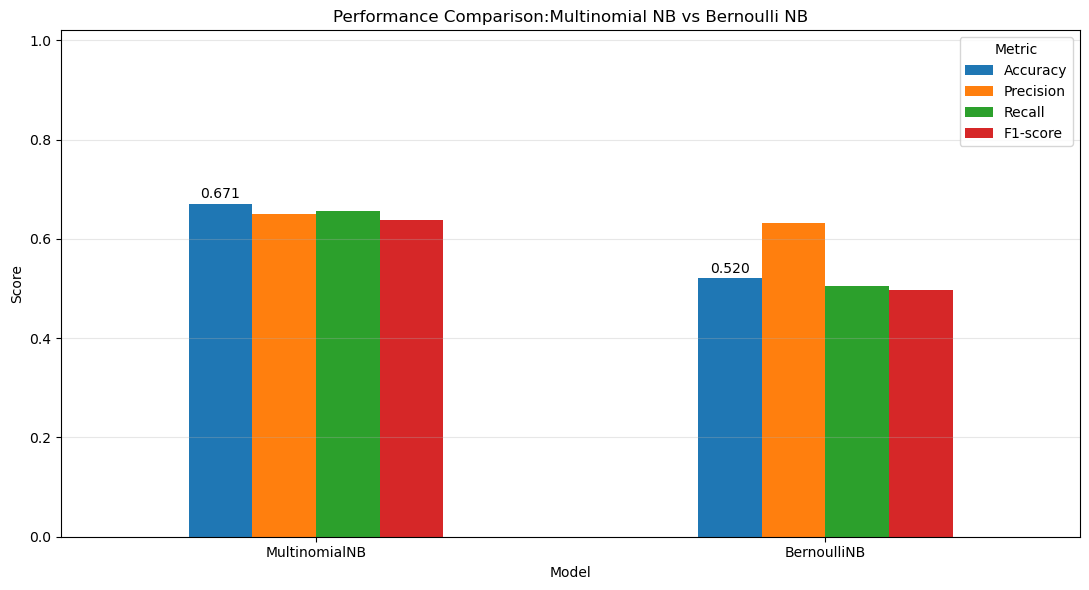

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [61]:
results_metrics=results[
    ["Model","Accuracy","Precision","Recall","F1-score"]
    ]
ax=results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)
plt.title(
    "Performance Comparison:Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)
for container in ax.containers:
    ax.bar_label(
        container,
        fmt ="%.3f",
        padding=2
    )
    plt.tight_layout()
    plt.show()